In [1]:
# ============================================================
# CELL 1: Imports, seeds, device
# ============================================================
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [2]:
# ============================================================
# CELL 2: Load corpus and create character-level tokenizer
# ============================================================
with open("corpus.txt", "r", encoding="utf-8") as f:
    text = f.read()

print("Corpus length:", len(text))

chars = sorted(list(set(text)))
vocab_size = len(chars)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

def encode(s):
    return [char_to_idx[c] for c in s]

def decode(ids):
    return "".join([idx_to_char[i] for i in ids])

data = torch.tensor(encode(text), dtype=torch.long)

split_idx = int(0.9 * len(data))
train_data = data[:split_idx]
val_data = data[split_idx:]

print("Vocab size:", vocab_size)
print("Train tokens:", len(train_data))
print("Val tokens:", len(val_data))

context_len = 128
batch_size = 64

def get_batch(split="train"):
    source = train_data if split == "train" else val_data
    ix = torch.randint(0, len(source) - context_len - 1, (batch_size,))
    x = torch.stack([source[i:i+context_len] for i in ix])
    y = torch.stack([source[i+1:i+context_len+1] for i in ix])
    return x.to(device), y.to(device)

Corpus length: 5458195
Vocab size: 91
Train tokens: 4912375
Val tokens: 545820


In [3]:
# ============================================================
# CELL 3: 3B.1 Build the Transformer
# ============================================================
class DecoderBlock(nn.Module):
    def __init__(self, d_model=64, n_heads=4, hidden_dim=256, dropout=0.1, norm_type="pre"):
        super().__init__()
        assert d_model % n_heads == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.norm_type = norm_type

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.ffn1 = nn.Linear(d_model, hidden_dim)
        self.ffn2 = nn.Linear(hidden_dim, d_model)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        self.ffn_dropout = nn.Dropout(dropout)

        self.last_attn = None

    def self_attention(self, x):
        B, T, C = x.shape

        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float("-inf"))

        attn = torch.softmax(scores, dim=-1)
        self.last_attn = attn.detach().cpu()

        attn = self.attn_dropout(attn)
        out = torch.matmul(attn, v)
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.out_proj(out)
        out = self.resid_dropout(out)
        return out

    def ffn(self, x):
        x = self.ffn1(x)
        x = F.gelu(x)
        x = self.ffn2(x)
        x = self.ffn_dropout(x)
        return x

    def forward(self, x):
        if self.norm_type == "pre":
            x = x + self.self_attention(self.norm1(x))
            x = x + self.ffn(self.norm2(x))
        else:
            x = self.norm1(x + self.self_attention(x))
            x = self.norm2(x + self.ffn(x))
        return x


class TinyTransformerLM(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=64,
        n_heads=4,
        n_layers=3,
        context_len=128,
        hidden_dim=256,
        dropout=0.1,
        norm_type="pre",
    ):
        super().__init__()

        self.context_len = context_len
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(context_len, d_model)
        self.drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            DecoderBlock(
                d_model=d_model,
                n_heads=n_heads,
                hidden_dim=hidden_dim,
                dropout=dropout,
                norm_type=norm_type,
            )
            for _ in range(n_layers)
        ])

        self.final_norm = nn.LayerNorm(d_model) if norm_type == "pre" else nn.Identity()
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, targets=None):
        B, T = x.shape
        assert T <= self.context_len, "Sequence length exceeds context window"

        pos = torch.arange(T, device=x.device)
        tok = self.token_emb(x)
        pos = self.pos_emb(pos)[None, :, :]
        x = self.drop(tok + pos)

        for block in self.blocks:
            x = block(x)

        x = self.final_norm(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.reshape(B * T, -1), targets.reshape(B * T))

        return logits, loss


model_pre = TinyTransformerLM(
    vocab_size=vocab_size,
    d_model=64,
    n_heads=4,
    n_layers=3,
    context_len=128,
    hidden_dim=256,
    dropout=0.1,
    norm_type="pre",
).to(device)

param_count = sum(p.numel() for p in model_pre.parameters())
print("Total parameter count:", param_count)

Total parameter count: 170011


In [ ]:
# ============================================================
# CELL 4: 3B.2 Pre-Norm vs Post-Norm training comparison
# ============================================================
@torch.no_grad()
def estimate_loss(model, eval_iters=100):
    model.eval()
    losses = {}
    for split in ["train", "val"]:
        split_losses = []
        for _ in range(eval_iters):
            xb, yb = get_batch(split)
            _, loss = model(xb, yb)
            split_losses.append(loss.item())
        losses[split] = sum(split_losses) / len(split_losses)
    model.train()
    return losses


def train_model(model, max_iters=30000, lr=3e-4, eval_interval=200):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_curve = []
    val_curve = []
    eval_steps = []

    model.train()
    for step in range(1, max_iters + 1):
        xb, yb = get_batch("train")
        _, loss = model(xb, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % eval_interval == 0 or step == 1:
            losses = estimate_loss(model, eval_iters=50)
            train_curve.append(losses["train"])
            val_curve.append(losses["val"])
            eval_steps.append(step)
            print(
                f"step {step:4d} | "
                f"train loss {losses['train']:.4f} | "
                f"val loss {losses['val']:.4f}"
            )

    return {
        "model": model,
        "train_curve": train_curve,
        "val_curve": val_curve,
        "eval_steps": eval_steps,
    }


model_pre = TinyTransformerLM(
    vocab_size=vocab_size,
    d_model=64,
    n_heads=4,
    n_layers=3,
    context_len=128,
    hidden_dim=256,
    dropout=0.1,
    norm_type="pre",
).to(device)

model_post = TinyTransformerLM(
    vocab_size=vocab_size,
    d_model=64,
    n_heads=4,
    n_layers=3,
    context_len=128,
    hidden_dim=256,
    dropout=0.1,
    norm_type="post",
).to(device)

pre_stats = train_model(model_pre, max_iters=30000, lr=3e-4, eval_interval=200)
post_stats = train_model(model_post, max_iters=30000, lr=3e-4, eval_interval=200)

plt.figure(figsize=(8, 5))
plt.plot(pre_stats["eval_steps"], pre_stats["train_curve"], label="Pre-Norm")
plt.plot(post_stats["eval_steps"], post_stats["train_curve"], label="Post-Norm")
plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.title("Pre-Norm vs Post-Norm Training Loss")
plt.legend()
plt.grid(True)
plt.show()

step    1 | train loss 4.5921 | val loss 4.5958
step  200 | train loss 2.7638 | val loss 2.7796
step  400 | train loss 2.5560 | val loss 2.5729
step  600 | train loss 2.4772 | val loss 2.4928
step  800 | train loss 2.4107 | val loss 2.4264
step 1000 | train loss 2.3552 | val loss 2.3773
step 1200 | train loss 2.3118 | val loss 2.3201
step 1400 | train loss 2.2605 | val loss 2.2758
step 1600 | train loss 2.2204 | val loss 2.2306


In [ ]:
# ============================================================
# CELL 5: 3B.3 Text generation
# ============================================================
def generate(model, prompt, max_len=200, temperature=1.0):
    model.eval()
    ids = torch.tensor(encode(prompt), dtype=torch.long, device=device).unsqueeze(0)

    generated = ids.clone()

    with torch.no_grad():
        for _ in range(max_len):
            idx_cond = generated[:, -model.context_len:]
            logits, _ = model(idx_cond)
            logits = logits[:, -1, :] / temperature
            probs = torch.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            generated = torch.cat([generated, next_id], dim=1)

    return decode(generated[0].tolist())


best_model = pre_stats["model"]

out_t1 = generate(best_model, prompt="The hero", max_len=200, temperature=1.0)
out_t02 = generate(best_model, prompt="The hero", max_len=200, temperature=0.2)
out_t15 = generate(best_model, prompt="The hero", max_len=200, temperature=1.5)

print("===== T = 1.0 =====")
print(out_t1)
print()
print("===== T = 0.2 =====")
print(out_t02)
print()
print("===== T = 1.5 =====")
print(out_t15)

===== T = 1.0 =====
The herous.
    O't is teddest will thou
    Much the was body be in Would That any our day of do he commance
    And a hands pray to heart, such the Taim all,
    To the is bired in a pray tussuriain; name t

===== T = 0.2 =====
The herour of the be so such the shall man the stand to me the fair the words and the man to me the man the counter.
                                                                                           

===== T = 1.5 =====
The herost
    dractaim From form aclwaotys.uve nog.
  RO, JIARD BALPA. We'll by to og
    Storale Confi.

  Gen. Her Cap.
  QUEENS. Is. Sir.
  YORK2. Liver's thouse of Shinch'd puttifer thy have; a. He walis


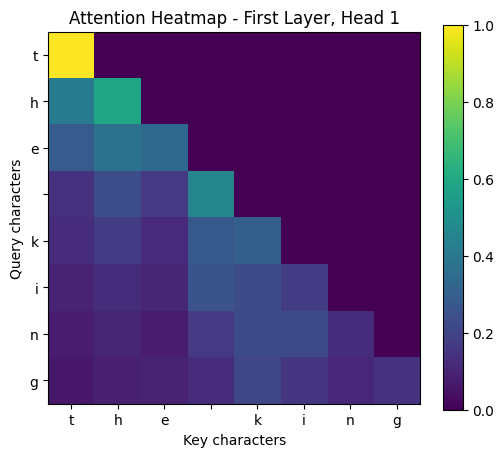

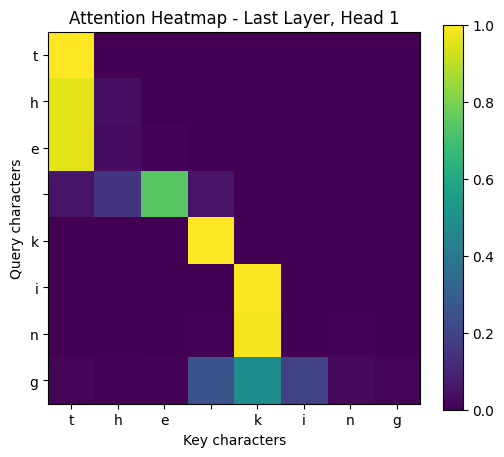

In [ ]:
# ============================================================
# CELL 6: 3B.4 Attention visualization
# ============================================================
def plot_attention_heatmap(attn_matrix, tokens, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(attn_matrix, cmap="viridis")
    plt.xticks(range(len(tokens)), tokens)
    plt.yticks(range(len(tokens)), tokens)
    plt.xlabel("Key characters")
    plt.ylabel("Query characters")
    plt.title(title)
    plt.colorbar()
    plt.show()


sample_text = "the king"
sample_ids = torch.tensor(encode(sample_text), dtype=torch.long, device=device).unsqueeze(0)

best_model.eval()
with torch.no_grad():
    _ = best_model(sample_ids)

first_layer_attn = best_model.blocks[0].last_attn[0, 0].numpy()
last_layer_attn = best_model.blocks[-1].last_attn[0, 0].numpy()

tokens = list(sample_text)

plot_attention_heatmap(
    first_layer_attn,
    tokens,
    "Attention Heatmap - First Layer, Head 1"
)

plot_attention_heatmap(
    last_layer_attn,
    tokens,
    "Attention Heatmap - Last Layer, Head 1"
)